### Amanda Cutler alc2282

In [16]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
SHA256 hash of downloaded file: a876cc7106e7dcb1344fbec5dcd7510e5cd947e62049a8cbc188ad05ffe00345
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


/home/alc2282/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


### 1.1 Open the dataset and display its contents

In [3]:
ds=xr.open_dataset('/home/alc2282/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc')

In [4]:
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (time: 203, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2 Print out the long_name attribute of each variable
Print variable: long name for each variable. Format the output so that the start of the long name attributes are aligned.

In [5]:
for var in ds.data_vars:
    print(f"{var}:{ds[var].attrs['long_name']}")

toa_sw_all_mon:Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon:Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon:Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon:Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon:Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon:Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon:Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon:Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon:Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon:Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon:Cloud Area Fraction, Monthly Means, Daytime-and-Nighttime conditions
cldpress_total_daynight_mon:Cloud Effective Pressure, Monthly Means, Daytime

### 2.1 Calculate the time-mean of the entire dataset

In [7]:
ds_mean = ds.mean(dim="time")
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lat: 180, lon: 360)
Coordinates:
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

### 2.2 From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation
(Use “All-Sky” conditions)

Note the sign conventions on each variable.

Text(0.5, 1.0, 'TOA Net Solar Flux as a Function of Longwave, Shortwave, and Incoming Solar Radiation')

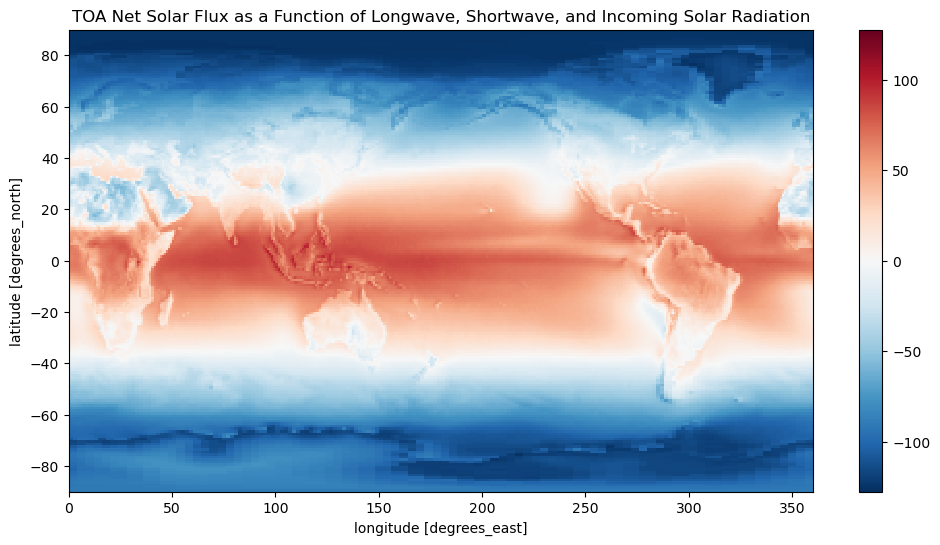

In [24]:
fig, ax = plt.subplots(figsize=(12,6))

(ds_mean['solar_mon']-ds_mean['toa_sw_all_mon']-ds_mean['toa_lw_all_mon']).plot(ax=ax)
ax.set_title('TOA Net Solar Flux as a Function of Longwave, Shortwave, and Incoming Solar Radiation')

### 2.3 Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux
You have to pay attention to and think carefully about the sign conventions (positive or negative) for each variable in order for the variables to sum to the right TOA net flux. Refer to the NASA figure at the top of the page to understand incoming and outgoing radiation.

Text(0.5, 1.0, 'TOA Net Flux')

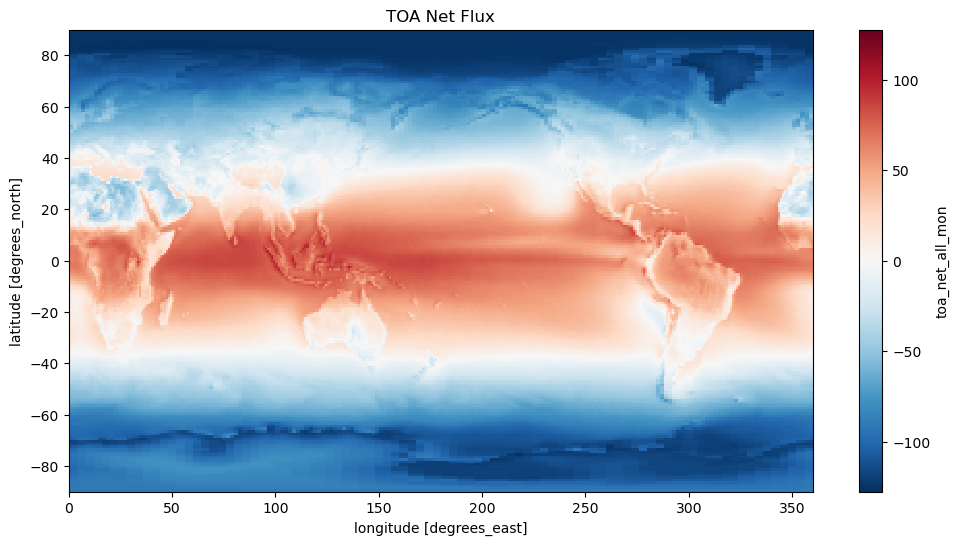

In [26]:
fig, ax = plt.subplots(figsize=(12,6))
ds_mean['toa_net_all_mon'].plot(ax=ax)
ax.set_title('TOA Net Flux')

### 3.1 Calculate the global (unweighted) mean of TOA net radiation
Since the Earth is approximately in radiative balance, the net TOA radiation should be zero. But taking the naive mean from this dataset, you should find a number far from zero. Why?

The answer is that each “pixel” or “grid point” of this dataset does not represent an equal area of Earth’s surface. So naively taking the mean, i.e. giving equal weight to each point, gives the wrong answer.

On a lat / lon grid, the relative area of each grid point is proportional to cos(lambda). (lambda
 is latitude)

In [33]:
unweighted_mean_net_toa = ds_mean['toa_net_all_mon'].mean().values
#unweighted_mean_net_toa

In [34]:
print(f"Unweighted global mean TOA net radiation: {unweighted_mean_net_toa:.4f} W/m²")

Unweighted global mean TOA net radiation: -28.7286 W/m²


### 3.2 Create a weight array proportional to lambda.
Think carefully a about radians vs. degrees

In [37]:
weights= np.cos(np.deg2rad(ds_mean.lat))
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

### 3.3 Redo your global mean TOA net radiation calculation with this weight factor
Use xarray’s weighted array reductions to compute the weighted mean.

This time around, you should have found something much closer to zero. Ask a climate scientist what the net energy imbalance of Earth due to global warming is estimated to be. Do you think our calculation is precise enough to detect this?

In [38]:
weighted_mean_net_toa = ds_mean['toa_net_all_mon'].weighted(weights).mean().values
#weighted_mean_net_toa
print(f"Weighted global mean TOA net radiation: {weighted_mean_net_toa:.4f} W/m²")

Weighted global mean TOA net radiation: 0.8781 W/m²


### 3.4 Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [42]:
print(f"Incoming Solar: {ds_mean['solar_mon'].weighted(weights).mean().values:.4f} W/m²")
print(f"Incoming Solar: {ds_mean['toa_sw_all_mon'].weighted(weights).mean().values:.4f} W/m²")
print(f"Incoming Solar: {ds_mean['toa_lw_all_mon'].weighted(weights).mean().values:.4f} W/m²")
print(f"Net Solar: {(ds_mean['solar_mon']-ds_mean['toa_sw_all_mon']-ds_mean['toa_lw_all_mon']).weighted(weights).mean().values:.4f} W/m²")

Incoming Solar: 340.2835 W/m²
Incoming Solar: 99.1386 W/m²
Incoming Solar: 240.2667 W/m²
Net Solar: 0.8781 W/m²


### 4.1 Calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it
(Xarray’s ones_like function can help you easily create and broadcast DataArrays.) Verify that the sum of all the pixels equals the Earth’s true surface area as evaluated using the formula for the area of a sphere (yes, the Earth is not a sphere … it’s just a homework problem).

In [62]:
#True surface area of the Earth 4*pi*(r-squared)
#Radius = 6371 km = 6.371e6 m
r = 6.371e6
true_sa = 4 * np.pi * r**2
true_sa
print(f"True surface area of the Earth: {true_sa} m²")

True surface area of the Earth: 510064471909788.25 m²


In [63]:
#Pixel area 
d_lat = np.deg2rad(1.0)
d_lon = np.deg2rad(1.0)
pixel_area = r**2 * np.cos(np.deg2rad(ds_mean.lat)) * d_lat * d_lon * xr.ones_like(ds_mean['toa_net_all_mon'])
total_pixel_area = pixel_area.sum().values
total_pixel_area
print(f"Total pixel area of the Earth: {total_pixel_area} m²")

Total pixel area of the Earth: 510070953607168.0 m²


### 4.2 Calculate and plot the total amount of net radiation in each 1-degree latitude band
Multiplying the pixel area (m^2) from above with the radiative flux (W m ^-2) gives you the total amount of radiation absorbed in each pixel in W.

Label with correct units.

In [64]:
rad_per_pixel = ds_mean['toa_net_all_mon'] * pixel_area
rad_per_lat_deg = rad_per_pixel.sum(dim='lon')

Text(0.5, 1.0, 'Net Radiation in Each 1-Degree Latitude Band')

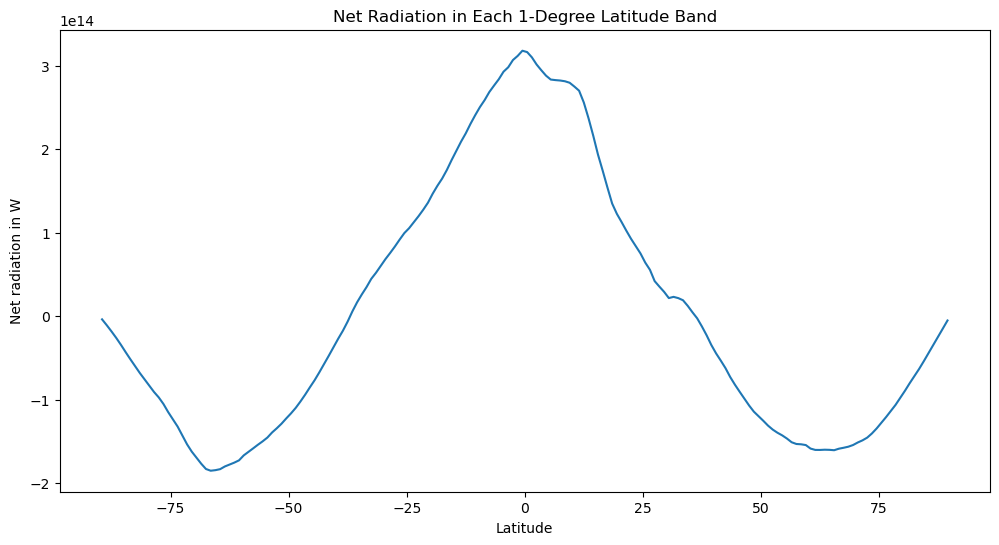

In [71]:
fig, ax = plt.subplots(figsize=(12,6))
rad_per_lat_deg.plot(ax=ax)
ax.set_xlabel('Latitude')
ax.set_ylabel('Net radiation in W')
ax.set_title('Net Radiation in Each 1-Degree Latitude Band')

### 4.3 Multiplying the pixel area (m^2) from above with the radiative flux (W m
) gives you the total amount of radiation absorbed in each pixel in W.

Label with correct units.

Label with correct units. (Hint: check out xarray’s cumsum function.)

This curve tells you how much energy must be transported meridionally by the ocean and atmosphere in order to account for the radiative imbalance at the top of the atmosphere.

You should get a curve that looks something like this: https://journals.ametsoc.org/view/journals/clim/14/16/full-i1520-0442-14-16-3433-f07.gif (Figure from Trenberth & Caron, 2001)

Text(0.5, 1.0, 'Meridonial Heat Transport vs. Latitude')

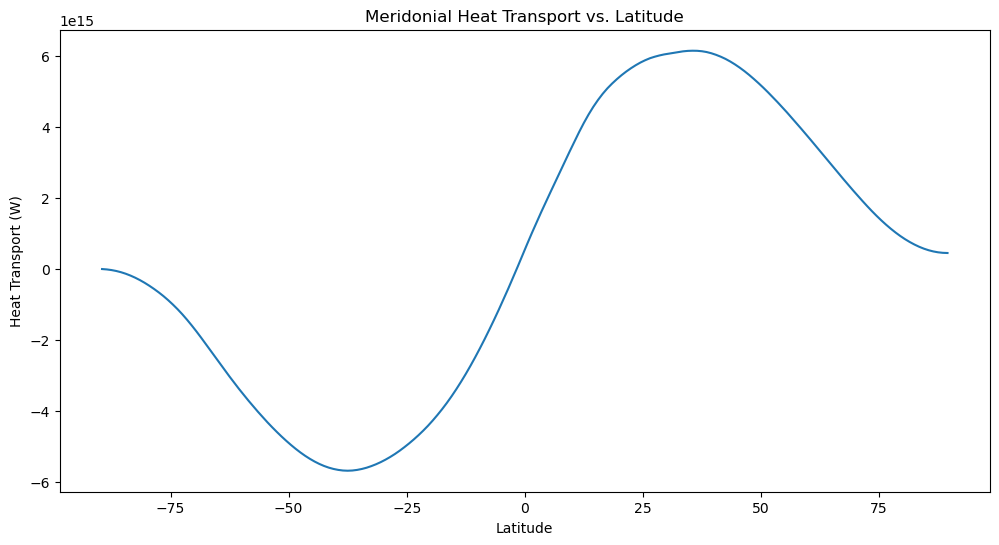

In [73]:
rad_cumsum = rad_per_lat_deg.cumsum(dim='lat')
fig, ax = plt.subplots(figsize=(12, 6))
rad_cumsum.plot(ax=ax)
ax.set_xlabel('Latitude')
ax.set_ylabel('Heat Transport (W)')
ax.set_title('Meridonial Heat Transport vs. Latitude')

### 5.2 Antarctic Sea Ice
Download this file and then use it to plot the concentration of Antarctic Sea Ice on Aug. 7, 2017. Again, you will need to explore the file contents in order to determine the correct projection.

In [5]:
import cartopy
import cartopy.crs as ccrs
import xarray as xr
import pooch

In [6]:
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

In [8]:
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

In [12]:
ds_ice['seaice_conc_cdr']

<xarray.DataArray 'seaice_conc_cdr' (time: 1, ygrid: 332, xgrid: 316)> Size: 420kB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid      (ygrid) float32 1kB 4.338e+06 4.312e+06 ... -3.912e+06 -3.938e+06
  * xgrid      (xgrid) float32 1kB -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
    latitude   (ygrid, xgrid) float64 839kB ...
    longitude  (ygrid, xgrid) float64 839kB ...
Attributes: (12/13)
    valid_range:            [  0 100]
    long_name:              NOAA/NSIDC Climate Data Record of Passive Microwa...
    standard_name:          sea_ice_area_fraction
    units:                  1
    flag_values:            [-5 -4 -3 -2 -1]
    flag_meanings:          pole_hole lakes coastal land_mask missing_data
    ...                     ...
    grid_mapping:           projection
    reference:              https://nsidc.org/api/dataset/metadata/v2/oai?ver...
    ancillary_variables:    stdev_of_seaice_conc_cdr qa_of_seaice_conc_cdr
    cell_methods:           time: mean (interval: 1 day)
    coverage_content_type:  physicalMeasurement
    ioos_category:          Ice Distribution

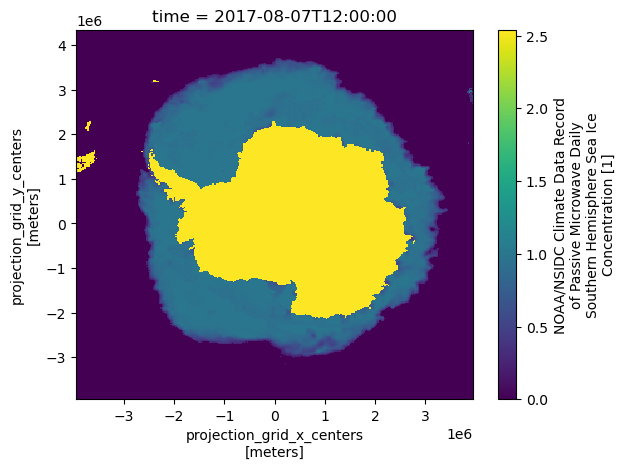

In [9]:
ds_ice['seaice_conc_cdr'].plot()

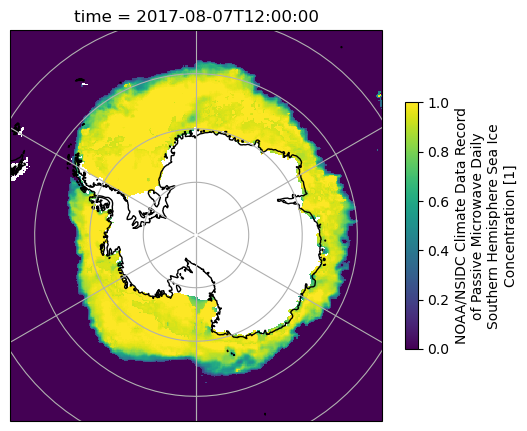

In [21]:
fig, ax = plt.subplots(figsize=(6,8),
                      subplot_kw={'projection':ccrs.SouthPolarStereo()}
                     )
ds_ice['seaice_conc_cdr'].where(ds_ice['seaice_conc_cdr'] <= 1).plot(ax=ax,
                                                                     transform=ccrs.SouthPolarStereo(),
                                                                     vmin=0, vmax=1,
                                                                    cbar_kwargs={'shrink': 0.4})
                                                                    
ax.gridlines()
ax.coastlines()

### 5.3 Global USGS Earthquakes
Reload the file we explored in homework 5 using pandas:
http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv
and use the data to recreate this map.

In [23]:
import pandas as pd

In [25]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [26]:
top50= df.nlargest(50,'mag')

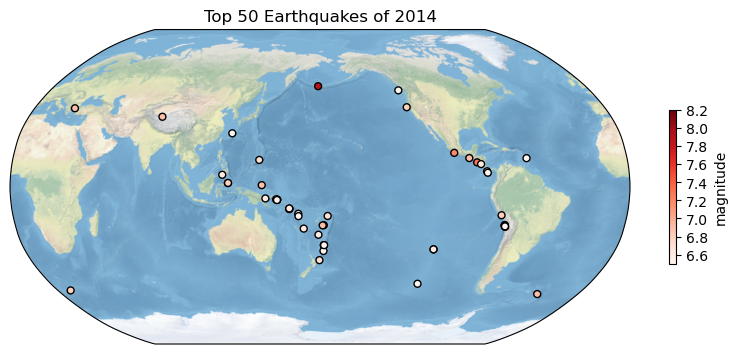

In [59]:
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
ax.stock_img()

sc1= ax.scatter(
    top50['longitude'], top50['latitude'],
    c=top50['mag'],
    cmap='Reds',
    s=25,
    edgecolors='k',
    transform=ccrs.PlateCarree()
)
ax.set_title('Top 50 Earthquakes of 2014')

plt.colorbar(sc1, ax=ax, label='magnitude', shrink=0.25, ticks=np.arange(6.6, 8.4, 0.2))